torch.Size([40, 1]) torch.Size([40, 1])
torch.Size([40, 1]) torch.Size([40, 1])
Total training COST/LOSS for epoch 1 is  0.1224
Total ACCURACY for epoch 1 is  0.7750
Total training COST/LOSS for epoch 2 is  0.1048
Total ACCURACY for epoch 2 is  0.7750
Total training COST/LOSS for epoch 3 is  0.0890
Total ACCURACY for epoch 3 is  0.7750
Total training COST/LOSS for epoch 4 is  0.0803
Total ACCURACY for epoch 4 is  0.7750
Total training COST/LOSS for epoch 5 is  0.0693
Total ACCURACY for epoch 5 is  0.7750
Total training COST/LOSS for epoch 6 is  0.0604
Total ACCURACY for epoch 6 is  0.9250
Total training COST/LOSS for epoch 7 is  0.0521
Total ACCURACY for epoch 7 is  0.9000
Total training COST/LOSS for epoch 8 is  0.0454
Total ACCURACY for epoch 8 is  0.9500
Total training COST/LOSS for epoch 9 is  0.0387
Total ACCURACY for epoch 9 is  0.9500
Total training COST/LOSS for epoch 10 is  0.0349
Total ACCURACY for epoch 10 is  0.9750
Total training COST/LOSS for epoch 11 is  0.0283
Total ACC

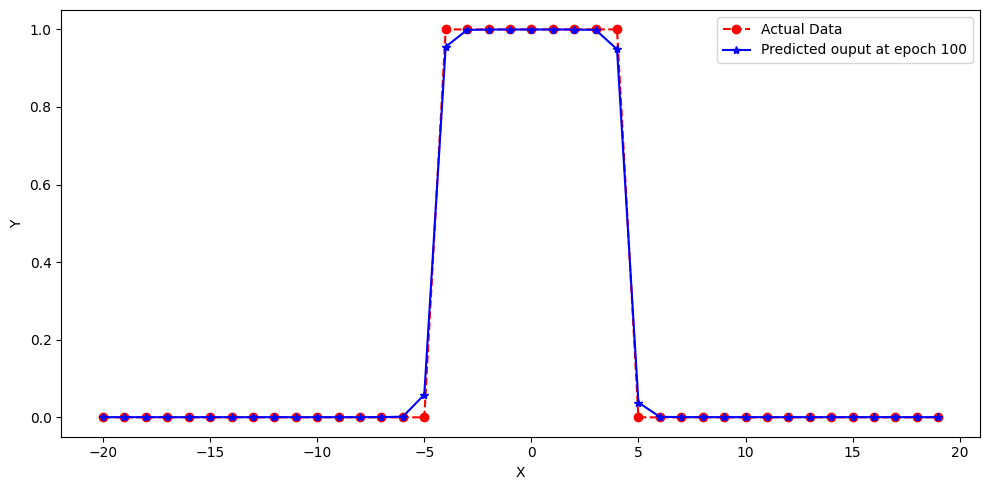

Total training COST/LOSS for epoch 1 is  0.1544
Total ACCURACY for epoch 1 is  0.9167
Total training COST/LOSS for epoch 2 is  0.0363
Total ACCURACY for epoch 2 is  0.9667
Total training COST/LOSS for epoch 3 is  0.0278
Total ACCURACY for epoch 3 is  0.9083
Total training COST/LOSS for epoch 4 is  0.0263
Total ACCURACY for epoch 4 is  0.9750
Total training COST/LOSS for epoch 5 is  0.0160
Total ACCURACY for epoch 5 is  0.9417
Total training COST/LOSS for epoch 6 is  0.0209
Total ACCURACY for epoch 6 is  0.9583
Total training COST/LOSS for epoch 7 is  0.0274
Total ACCURACY for epoch 7 is  0.9333
Total training COST/LOSS for epoch 8 is  0.0381
Total ACCURACY for epoch 8 is  0.9667
Total training COST/LOSS for epoch 9 is  0.0219
Total ACCURACY for epoch 9 is  0.9667
Total training COST/LOSS for epoch 10 is  0.0285
Total ACCURACY for epoch 10 is  0.9333
Total training COST/LOSS for epoch 11 is  0.0286
Total ACCURACY for epoch 11 is  0.9417
Total training COST/LOSS for epoch 12 is  0.0407
T

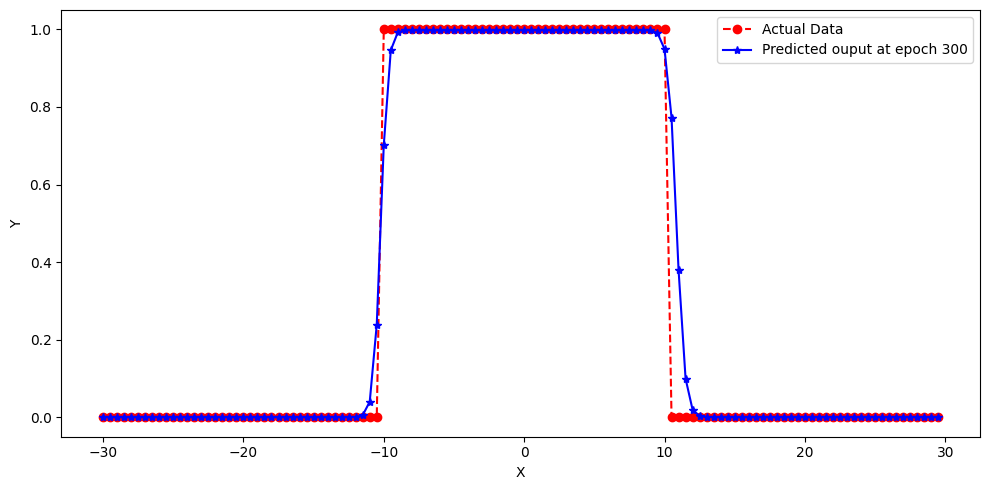

In [30]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset,DataLoader
import torch.optim as optim

torch.manual_seed(0)

def plot_graph(X,Y, epoch, model=None):
    plt.figure(figsize=(10,5))
    plt.plot(X.numpy(),Y.numpy(),marker='o',ls='--',color='r',label='Actual Data')
    if model != None:
        plt.plot(X.numpy(), model(X).detach().numpy(), marker = '*',color='b',label=('Predicted ouput at epoch ' + str(epoch)))
    
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend()
    plt.tight_layout()
    plt.show()

X = torch.arange(-20,20,1).view(-1,1).type(torch.float32)
Y = torch.zeros(X.shape[0])
Y[(X[:,0]>=-4) & (X[:,0]<=4)] =1
Y = Y.view(-1,1)

class Data(Dataset):

    def __init__(self,X,Y):
        super().__init__()
        self.X = X
        self.Y = Y
        self.len = self.X.shape[0]

    def __getitem__(self,index):
        return self.X[index], self.Y[index]
    
    def __len__(self):
        return self.len
    
train_dataset = Data(X, Y)
train_loader = DataLoader(dataset=train_dataset, batch_size=5,shuffle=True)

test_dataset = Data(X,Y)
test_loader = DataLoader(dataset=test_dataset, batch_size=10,shuffle=True)
print(train_dataset.X.shape, train_dataset.Y.shape)
print(test_dataset.X.shape, test_dataset.Y.shape)


model = nn.Sequential( nn.Linear(1,7), nn.Sigmoid(), nn.Linear(7,1), nn.Sigmoid())
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr= 0.1)

COST = [] 
ACCURACY = []

epochs =100 
def train_model(epochs):
    for epoch in range(epochs):
        running_loss = 0
        acc = 0
        for x,y in train_loader:
            yhat = model(x)
            optimizer.zero_grad()
            loss = criterion(yhat,y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        COST.append( running_loss / len(train_dataset))
        print(f"Total training COST/LOSS for epoch {epoch+1} is {COST[-1]: .4f}")
        with torch.no_grad():
            for x_test, y_test in test_loader:
                yhat_test = model(x_test)
                test_preds = (yhat_test > 0.5).float()
                acc += (test_preds == y_test).sum().item()
        ACCURACY.append(acc/len(test_dataset))
        print(f"Total ACCURACY for epoch {epoch+1} is {ACCURACY[-1]: .4f}")

train_model(epochs)

plot_graph(test_dataset.X,test_dataset.Y, epochs, model)

# Reset tracking lists
COST.clear()
ACCURACY.clear()

X = torch.arange(-30,30,0.5).view(-1,1).type(torch.float32)
Y = torch.zeros(X.shape[0])
Y[(X[:,0]>=-10) & (X[:,0]<=10)] =1
Y = Y.view(-1,1)



epochs =300 
model = nn.Sequential( nn.Linear(1,15), nn.ReLU(), nn.Linear(15,1), nn.Sigmoid())
optimizer = optim.Adam(model.parameters(), lr= 0.1)

# Missing before second train_model() call:
train_dataset = Data(X, Y)
train_loader = DataLoader(dataset=train_dataset, batch_size=5, shuffle=True)
test_dataset = Data(X, Y)
test_loader = DataLoader(dataset=test_dataset, batch_size=10, shuffle=True)
train_model(epochs)

plot_graph(X,Y, epochs, model)
